Part A — Student Information

Name: TANVI
PRN: 202401110010
Class: T.Y.
Batch: A2
Course: Generative AI Lab
Department: CSE AIML

Part B — Objective

To implement a simple feedforward neural network from scratch in Python
without using built-in deep learning libraries. The network performs binary
classification on the Banknote Authentication dataset using forward
propagation, backpropagation and gradient descent.

Dataset section

Dataset: Banknote Authentication Dataset

The dataset contains 1372 instances and 4 numerical features:
1. Variance
2. Skewness
3. Curtosis
4. Entropy

The target variable represents whether the banknote is genuine or forged.
This is a binary classification problem.

## Neural Network Architecture

The neural network consists of three layers:

**Input Layer:** 4 neurons  
- Represents the four features of the Banknote Authentication dataset.

↓  

**Hidden Layer:** 8 neurons  
- Activation Function: ReLU

↓

**Output Layer:** 1 neuron  
- Activation Function: Sigmoid

↓

**Output:** Genuine / Forged

### Network Structure

4 Input Neurons → 8 Hidden Neurons → 1 Output Neuron

**Architecture:** 4 → 8 → 1


Main code

Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load dataset

In [2]:
df = pd.read_csv("data_banknote_authentication.txt")

print(df.head())
print(df.shape)
print(df.info())

    3.6216  8.6661  -2.8073  -0.44699  0
0  4.54590  8.1674  -2.4586  -1.46210  0
1  3.86600 -2.6383   1.9242   0.10645  0
2  3.45660  9.5228  -4.0112  -3.59440  0
3  0.32924 -4.4552   4.5718  -0.98880  0
4  4.36840  9.6718  -3.9606  -3.16250  0
(1371, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371 entries, 0 to 1370
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   3.6216    1371 non-null   float64
 1   8.6661    1371 non-null   float64
 2   -2.8073   1371 non-null   float64
 3   -0.44699  1371 non-null   float64
 4   0         1371 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None


Separate features and target

In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (1371, 4)
Target shape: (1371, 1)


Train-test split

In [4]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1096
Testing samples: 275


Standardization

In [5]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

Activation functions

ReLU

In [6]:
def relu(x):
    return np.maximum(0, x)

ReLU derivative

In [7]:
def relu_derivative(x):
    return (x > 0).astype(float)

Sigmoid

In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

Initialize neural network

In [9]:
np.random.seed(42)

input_size = 4
hidden_size = 8
output_size = 1

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

Forward propagation

In [10]:
def forward_pass(X):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2

Binary Cross Entropy

In [11]:
def binary_cross_entropy(y, y_pred):
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -(y * np.log(y_pred) +
             (1 - y) * np.log(1 - y_pred))

    return np.mean(loss)

Backpropagation

In [12]:
def backward_pass(X, y, Z1, A1, A2):

    m = X.shape[0]

    dZ2 = A2 - y
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

Gradient Descent training

In [13]:
learning_rate = 0.1
epochs = 1000

loss_history = []

for epoch in range(epochs):

    # Forward pass
    Z1, A1, Z2, A2 = forward_pass(X_train)

    # Calculate loss
    loss = binary_cross_entropy(y_train, A2)
    loss_history.append(loss)

    # Backpropagation
    dW1, db1, dW2, db2 = backward_pass(
        X_train, y_train, Z1, A1, A2
    )

    # Gradient descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss:.4f}")

Epoch 100, Loss: 0.6748
Epoch 200, Loss: 0.3905
Epoch 300, Loss: 0.1248
Epoch 400, Loss: 0.0728
Epoch 500, Loss: 0.0563
Epoch 600, Loss: 0.0483
Epoch 700, Loss: 0.0436
Epoch 800, Loss: 0.0403
Epoch 900, Loss: 0.0379
Epoch 1000, Loss: 0.0361


Loss graph

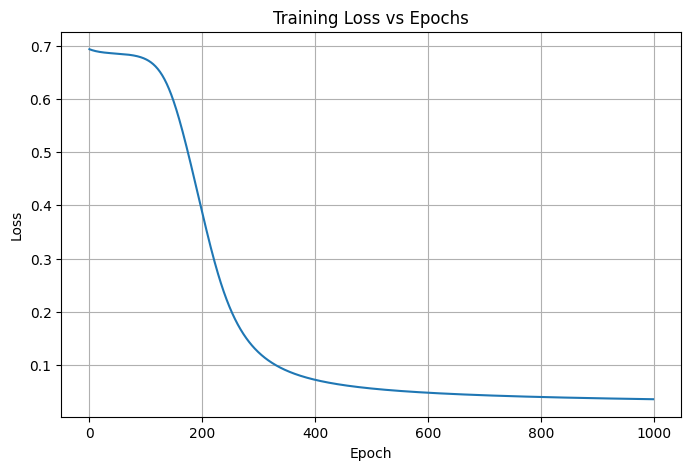

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")

plt.grid(True)
plt.show()

Prediction

In [15]:
_, _, _, predictions = forward_pass(X_test)

predicted_classes = (predictions >= 0.5).astype(int)

accuracy = np.mean(predicted_classes == y_test) * 100

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.27%


Prediction result

In [16]:
comparison = pd.DataFrame({
    "Actual": y_test.flatten(),
    "Predicted": predicted_classes.flatten()
})

print(comparison.head(20))

    Actual  Predicted
0        1          1
1        0          0
2        0          0
3        0          0
4        1          1
5        0          0
6        0          0
7        1          1
8        1          1
9        1          1
10       1          1
11       1          1
12       0          0
13       1          1
14       0          0
15       0          0
16       0          0
17       1          1
18       0          0
19       0          0
